# Modeling #

Given that the goal of this model is to make a numerical prediction, I believe using a regression model would be best.

In this section, we'll be using different models to try to identify which one is the best fit. We'll be using the following models:
- Linear Regression
- Random Forest

## Imports
#### Packages

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import re
import sklearn
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
# Linear Regression 
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, KFold
# Random Forest imports
from sklearn.ensemble import RandomForestRegressor


#### Loading Data

In [2]:
modeling_data_dir = ('../data/processed/modeling/')

X_train = pd.read_csv(modeling_data_dir + 'X_train.csv', index_col='row_id')
X_test = pd.read_csv(modeling_data_dir + 'X_test.csv', index_col='row_id')
y_train = pd.read_csv(modeling_data_dir + 'y_train.csv', index_col='row_id')['salary_midpoint']
y_test = pd.read_csv(modeling_data_dir + 'y_test.csv', index_col='row_id')['salary_midpoint']

#### Modeling decisions

- **Starting with Linear Regression:**  Since the goal is to predict a salary, a numeric number, linear regression seemed like a good starting point. It is a simple model that makes it easier to see how each feature relates to the prediction. It assumes that the features have a linear relationship with salary, but salary itself does not need to follow a normal distribution.
- **Removing two category columns:** Education and experience each have a separate column for every category. Since the model also includes a starting value called an intercept, keeping all of these columns would give it repeated information. I removed 'education_bachelors' and 'experience_Entry' so the model can use Bachelor's and Entry as the comparison groups for the other categories.
- **Keeping the current feature scales:** I did not add a scaling step because ordinary Linear Regression does not penalize large coefficients, and rescaling the features should not change its predictions. This also lets me read the coefficients in salary dollars for a one-unit change in a feature. The years feature is already scaled from 0 to 1, so its coefficient describes the predicted difference between the lowest and highest experience requirements in that scale.
- **Checking the model with five folds:** I split the training data into five groups. The model trains on four groups and is checked on the remaining group, repeating this until each group has been used for checking. This helps me see whether the model performs similarly across different parts of the data. I used a fixed random seed so I can repeat the same splits.
- **Comparing prediction errors:** I used mean absolute error (MAE) as the main score because it tells me how far off the predictions are on average in dollars. I also included RMSE, which puts more weight on large mistakes, and R², which shows how much of the variation in salary the model explains.
- **Comparing against a simple guess:** I compared the model with one that predicts the average training salary for every job. This helps me check whether using the job features improves predictions over just using the average.


#### Preparing the data

In [3]:
# Confirm that every feature row matches the correct target row.
# Matching indexes prevent salaries from being paired with the wrong job postings.
train_rows_match = X_train.index.equals(y_train.index)
test_rows_match = X_test.index.equals(y_test.index)

if not train_rows_match or not test_rows_match:
    raise ValueError('Feature and target row IDs are not aligned')

In [4]:
# Models in this notebook require complete numeric data.
# Check both features and targets before fitting any model.
training_features_have_missing_values = X_train.isna().any().any()
training_target_has_missing_values = y_train.isna().any()

if training_features_have_missing_values or training_target_has_missing_values:
    raise ValueError('Training data contains missing values')

In [5]:
# Use Bachelor's degree and Entry level as reference categories.
# Dropping one indicator from each category avoids perfect multicollinearity.
reference_columns = [
    'education_bachelors',
    'experience_Entry',
]

X_train_linear = X_train.drop(columns=reference_columns)
X_test_linear = X_test.drop(columns=reference_columns)

#### Cross validation and model fitting

In [6]:
# Create an ordinary least-squares regression model.
linear_model = LinearRegression()

# KFold defines how the training data will be divided for cross validation.
# shuffle=True mixes the row order before creating the five folds.
# random_state makes those folds reproducible.
linear_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

In [7]:
# Train and validate the model five times.
# Scikit-learn returns negative MAE because it treats larger scores as better.
# Multiplying by -1 converts the scores back into positive dollar errors.
linear_cv_mae = -cross_val_score(
    estimator=linear_model,
    X=X_train_linear,
    y=y_train,
    cv=linear_cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)

print(f'Mean validation MAE: ${linear_cv_mae.mean():,.0f}')
print(f'Validation MAE standard deviation: ${linear_cv_mae.std():,.0f}')

Mean validation MAE: $9,757
Validation MAE standard deviation: $159


In [8]:
# Fit one final linear model using all available training rows.
# This fitted model will make predictions for the untouched test rows.
linear_model.fit(X_train_linear, y_train)

LinearRegression()

The cross-validation mean estimates the model's typical error on unseen training-like rows. Its standard deviation shows how much that estimate changed among folds. A small standard deviation relative to the mean suggests that performance is reasonably stable across these splits.

#### Test-set predictions and metrics

In [9]:
# Use the fitted linear model to predict salary midpoints for the test set.
linear_predictions = linear_model.predict(X_test_linear)

In [ ]:
# Building a simple comparison model that predicts the training-set mean.
# A useful model should perform  better than the baseline.
linear_baseline = DummyRegressor(strategy='mean')
linear_baseline.fit(X_train_linear, y_train)
linear_baseline_predictions = linear_baseline.predict(X_test_linear)

In [11]:
# Comparing the linear model to the baseline model on the test set with this
def regression_metrics(actual, predicted):
    """Return three common regression metrics for a set of predictions."""
    # MAE is the average absolute prediction error in salary dollars.
    mae = mean_absolute_error(actual, predicted)

    # RMSE gives additional weight to unusually large prediction errors.
    rmse = mean_squared_error(actual, predicted) ** 0.5

    # R squared measures the share of target variation explained by the model.
    r_squared = r2_score(actual, predicted)

    return {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r_squared,
    }

In [12]:
# Put baseline and linear-model results into one table for comparison.
linear_results = pd.DataFrame({
    'Mean baseline': regression_metrics(y_test, linear_baseline_predictions),
    'Linear regression': regression_metrics(y_test, linear_predictions),
}).T

linear_results

,MAE,RMSE,R²
Mean baseline,40566.999697,48596.955725,-0.001553
Linear regression,9497.197050,12127.472434,0.937627


#### Reading the coefficients

Each coefficient is the predicted salary-midpoint change associated with that feature when all other included features are held fixed. For example, 'experience_Mid' compares Mid with the omitted Entry category. Skill coefficients compare postings containing that skill with otherwise identical postings without it. Because predictors can be correlated, these are adjusted associations rather than causal effects.

In [13]:
# Match every fitted coefficient with its feature name.
linear_coefficients = pd.Series(
    data=linear_model.coef_,
    index=X_train_linear.columns,
    name='coefficient',
)

# Sort by absolute size so the strongest model associations appear first.
linear_coefficients = linear_coefficients.sort_values(
    key=abs,
    ascending=False,
)

print(f'Intercept: ${linear_model.intercept_:,.0f}')
linear_coefficients.to_frame()

Intercept: $104,571


,coefficient
experience_Senior,125947.197301
experience_Mid,45375.451093
years_experience_normalized,4881.654763
skill_supervised_learning,2185.623521
skill_ci_cd,1267.381100
skill_lightgbm,-1050.969533
skill_regression,-938.482013
education_masters,-898.850994
skill_scikit_learn,-857.416964
skill_pytorch,-825.210930


#### Diagnostic plots

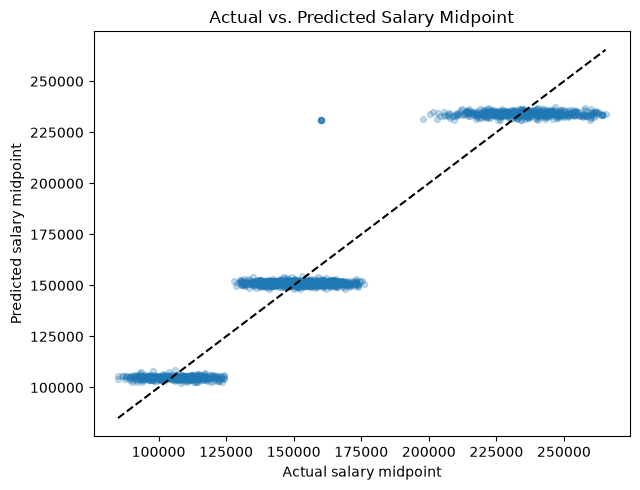

In [14]:
# Plot actual salaries against model predictions.
plt.figure(figsize=(6.5, 5))
plt.scatter(y_test, linear_predictions, alpha=0.25, s=18)

# Create a diagonal line showing where perfect predictions would fall.
linear_limits = [
    min(y_test.min(), linear_predictions.min()),
    max(y_test.max(), linear_predictions.max()),
]
plt.plot(linear_limits, linear_limits, '--', color='black')

plt.title('Actual vs. Predicted Salary Midpoint')
plt.xlabel('Actual salary midpoint')
plt.ylabel('Predicted salary midpoint')
plt.tight_layout()
plt.show()

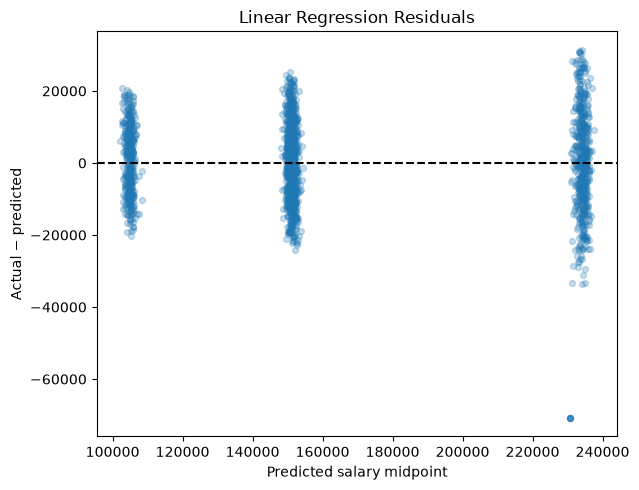

In [15]:
# A residual is the actual value minus the predicted value.
linear_residuals = y_test - linear_predictions

plt.figure(figsize=(6.5, 5))
plt.scatter(linear_predictions, linear_residuals, alpha=0.25, s=18)

# The horizontal line marks zero error.
plt.axhline(0, linestyle='--', color='black')
plt.title('Linear Regression Residuals')
plt.xlabel('Predicted salary midpoint')
plt.ylabel('Actual − predicted')
plt.tight_layout()
plt.show()

The diagonal in the first plot represents perfect predictions. Points above it were underpredicted, while points below it were overpredicted. In the residual plot, a strong curve would suggest that a straight-line relationship is missing structure. A widening spread would suggest that error variance changes across predicted salary levels.

For the current split, Linear Regression produced a cross-validation MAE of approximately **$9,757** with a fold-to-fold standard deviation of approximately **$159**. Its test MAE was approximately **$9,497**, test RMSE was approximately **$12,127**, and test R^2 was approximately **0.938**. The mean baseline's test MAE was approximately **$40,567**. Experience-level indicators had the largest coefficients, which agrees with the earlier exploratory analysis.

### Model 2: Random Forest Regression

Random Forest combines many decision trees to make a prediction. Each tree splits job postings into smaller groups by asking questions about features, such as experience level. It predicts a salary using the average salary in the final group. The forest then averages the predictions from all its trees.

I also have previous experience working with Random Forests and wanted to see how it could be applied here.

#### Modeling decisions

- **Trying a different model:** I wanted to see whether Random Forest could improve on Linear Regression. Trees can pick up patterns where a feature's relationship with salary changes depending on other features.
- **Keeping all the features:** I used the full feature set loaded at the start of the notebook, including all education and experience columns. Trees do not need the reference categories used for Linear Regression. They also do not need an extra scaling step, so I kept the existing years-of-experience feature as it is.
- **Limiting how detailed trees can get:** 'max_depth' controls how many splits a tree can make along a path. I tried 8 and 'None', which means no depth limit. 'min_samples_leaf' sets the smallest number of training rows allowed in a final group. I tried 1 and 5. These settings can help prevent a tree from learning details that do not carry over to new postings.
- **Combining different trees:** Each tree trains on a random sample of the training rows, with some rows picked more than once. 'max_features' controls how many features it considers at each split. I tried half the features ('0.5') and all of them ('1.0'). I used 150 trees, set with 'n_estimators', to keep the search time manageable.
- **Choosing the settings:** I used 'GridSearchCV' to try all eight combinations with the same five folds and random seed used for Linear Regression. I chose the combination with the lowest validation MAE. The search uses only the training data, then fits the selected forest on all training rows before making test predictions.

#### Checking the input data

I used 'X_train' and 'X_test' directly because they still contain all the feature columns.

In [16]:
# Reuse the full numeric feature sets loaded at the start of the notebook.
if not X_train.index.equals(y_train.index) or not X_test.index.equals(y_test.index):
    raise ValueError('Feature and target row IDs are not aligned')

if not X_train.columns.equals(X_test.columns):
    raise ValueError('Training and test feature columns do not match')

if X_train.isna().any().any() or y_train.isna().any():
    raise ValueError('Training data contains missing values')

#### Trying different Random Forest settings

In [17]:
# Parallelize the search, while each individual forest uses one worker.
# This avoids starting parallel work at both levels at once.
forest_estimator = RandomForestRegressor(
    n_estimators=150,
    random_state=42,
    n_jobs=1,
)

forest_parameters = {
    'max_depth': [8, None],
    'min_samples_leaf': [1, 5],
    'max_features': [0.5, 1.0],
}

forest_cv = KFold(n_splits=5, shuffle=True, random_state=42)
forest_search = GridSearchCV(
    estimator=forest_estimator,
    param_grid=forest_parameters,
    scoring='neg_mean_absolute_error',
    cv=forest_cv,
    n_jobs=-1,
    return_train_score=True,
)

In [18]:
# GridSearchCV automatically refits the winning settings on all training rows.
forest_search.fit(X_train, y_train)
forest_model = forest_search.best_estimator_
forest_best_index = forest_search.best_index_
forest_cv_mae = -forest_search.best_score_
forest_cv_std = forest_search.cv_results_['std_test_score'][forest_best_index]

print(f'Best settings: {forest_search.best_params_}')
print(f'Mean validation MAE: ${forest_cv_mae:,.0f}')
print(f'Validation MAE standard deviation: ${forest_cv_std:,.0f}')

Best settings: {'max_depth': 8, 'max_features': 0.5, 'min_samples_leaf': 5}
Mean validation MAE: $9,560
Validation MAE standard deviation: $110


#### Checking for overfitting

In [19]:
# Compare errors on each fold's training rows with its validation rows.
# In cv_results_, "test_score" means the validation fold, not X_test.
forest_search_results = pd.DataFrame(forest_search.cv_results_)
forest_validation_results = pd.DataFrame({
    'max_depth': forest_search_results['param_max_depth'],
    'min_samples_leaf': forest_search_results['param_min_samples_leaf'],
    'max_features': forest_search_results['param_max_features'],
    'Training MAE': -forest_search_results['mean_train_score'],
    'Validation MAE': -forest_search_results['mean_test_score'],
    'Validation MAE std': forest_search_results['std_test_score'],
}).sort_values('Validation MAE')

forest_validation_results

,max_depth,min_samples_leaf,max_features,Training MAE,Validation MAE,Validation MAE std
1,8,5,0.5,9258.588069,9559.794231,110.457516
3,8,5,1.0,9215.728234,9581.736162,115.892823
0,8,1,0.5,9073.855168,9585.279503,107.387543
2,8,1,1.0,9027.352691,9605.619907,115.240966
5,None,5,0.5,9130.949134,9636.460886,124.483370
7,None,5,1.0,9064.009350,9691.179940,144.387434
4,None,1,0.5,8097.968016,10087.257029,144.754094
6,None,1,1.0,8102.554776,10099.539874,152.961936


Overfitting happens when a model learns details in the training data that do not help it predict new rows. One sign is a much lower training error than validation error.

I compared both errors in the table above, but used validation MAE to choose the settings. A tree that fits the training rows more closely is not always better at predicting salaries for other postings.

#### Test-set predictions and model comparison

In [20]:
forest_predictions = forest_model.predict(X_test)

# Reuse the baseline, earlier predictions, and regression_metrics helper.
forest_results = pd.DataFrame({
    'Mean baseline': regression_metrics(y_test, linear_baseline_predictions),
    'Linear regression': regression_metrics(y_test, linear_predictions),
    'Random forest': regression_metrics(y_test, forest_predictions),
}).T

forest_results

,MAE,RMSE,R²
Mean baseline,40566.999697,48596.955725,-0.001553
Linear regression,9497.197050,12127.472434,0.937627
Random forest,9250.283946,11403.416101,0.944853


I compared Random Forest with Linear Regression and the same mean baseline using the same test rows. This lets me check whether the extra model complexity leads to a useful improvement.

#### Looking at feature importance

Random Forest does not have coefficients like Linear Regression. Instead, its feature importance scores show how much each feature helped the trees reduce prediction errors during training. The scores add up to 1, and a larger score means the model relied more on that feature by this measure.

These scores do not tell me whether a feature raises or lowers a salary, or by how many dollars. Features with more possible split points can receive higher scores. Related features, such as years of experience and experience level, can also share importance. I used these scores to understand the model, not as proof that a feature causes a salary change.

In [21]:
forest_importances = pd.Series(
    forest_model.feature_importances_,
    index=X_train.columns,
    name='importance',
).sort_values(ascending=False)

forest_importances.to_frame()

,importance
years_experience_normalized,0.557325
experience_Senior,0.260228
experience_Entry,0.105398
experience_Mid,0.045398
education_phd,0.023714
education_bachelors,0.005080
education_masters,0.000739
skill_pytorch,0.000238
skill_triton_inference_server,0.000202
skill_pandas,0.000177


#### Random Forest diagnostic plots

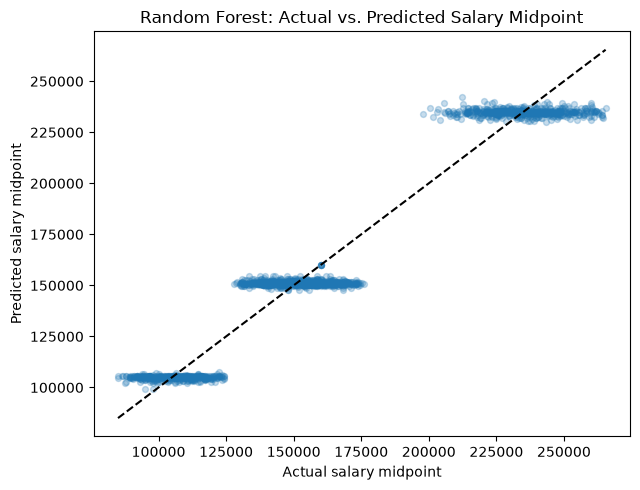

In [22]:
# Use the same actual-versus-predicted plot as the Linear Regression.
plt.figure(figsize=(6.5, 5))
plt.scatter(y_test, forest_predictions, alpha=0.25, s=18)
forest_limits = [
    min(y_test.min(), forest_predictions.min()),
    max(y_test.max(), forest_predictions.max()),
]
plt.plot(forest_limits, forest_limits, '--', color='black')
plt.title('Random Forest: Actual vs. Predicted Salary Midpoint')
plt.xlabel('Actual salary midpoint')
plt.ylabel('Predicted salary midpoint')
plt.tight_layout()
plt.show()

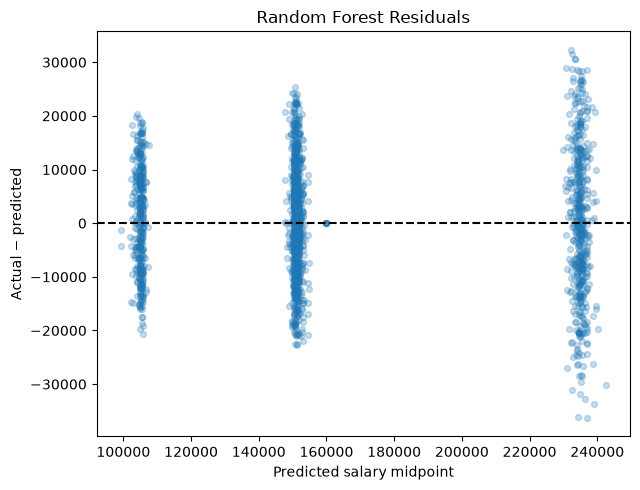

In [23]:
# Calculate the forest residuals for the same comparison.
forest_residuals = y_test - forest_predictions
plt.figure(figsize=(6.5, 5))
plt.scatter(forest_predictions, forest_residuals, alpha=0.25, s=18)
plt.axhline(0, linestyle='--', color='black')
plt.title('Random Forest Residuals')
plt.xlabel('Predicted salary midpoint')
plt.ylabel('Actual − predicted')
plt.tight_layout()
plt.show()

I used the same plots as in the Linear Regression section to check for patterns in the remaining errors. One limitation of this forest is that it averages salaries from the training data, so it cannot predict salaries outside the training salary range.

#### What I learned

The search selected 'max_depth=8', 'min_samples_leaf=5', and 'max_features=0.5'. The validation MAE was about **$9,560**, with a standard deviation of **$110** across folds. The training MAE for these settings was about **$9,259**. Trees with no depth limit and one-row leaves had a lower training MAE of about **$8,100**, but a higher validation MAE of about **$10,100**. This suggests that allowing more detailed trees did not help with new predictions.

On the test set, Random Forest had an MAE of about **$9,250**, compared with **$9,497** for Linear Regression and **$40,567** for the mean baseline. That is about **$247**, or **2.6%**, less average error than Linear Regression. Its RMSE was about **$11,403**, and its R² was about **0.945**.

Years of experience and the experience-level columns had the highest importance scores. This suggests that the forest relied mostly on experience when predicting salaries.

### Best Model?

Random Forest performed best on this test split, although its improvement over Linear Regression was small.

- **MAE:** Random Forest had about 2.6% less average error than Linear Regression.
- **RMSE:** Random Forest had about 6% lower RMSE, suggesting it also reduced some of the larger mistakes.
- **R²:** Random Forest explained about 94.5% of the salary variation, compared with 93.8% for Linear Regression.

Based on these results, I would choose Random Forest for its slightly better predictions. Linear Regression is still a useful option because its results were close and its coefficients are easier to interpret. These results come from one test split, so they do not show that Random Forest will always perform better. If I use these test results to guide more model changes, I would need a fresh set of held-out data for a final check.